In [8]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

from PIL import Image

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

from tensorflow.image import psnr, ssim

In [9]:
import tarfile

compressed_file = '/content/lines.tgz' # Adjust if you uploaded to Drive
extract_path = '/content/iam_lines_data'

if not os.path.exists(extract_path):
    print("Extracting dataset... this may take a moment.")
    with tarfile.open(compressed_file, "r:gz") as tar:
        tar.extractall(path=extract_path)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

sample_path = os.path.join(extract_path, 'a01/a01-000u/a01-000u-00.png')
if os.path.exists(sample_path):
    print(f"Verified: {sample_path} exists.")

Dataset already extracted.
Verified: /content/iam_lines_data/a01/a01-000u/a01-000u-00.png exists.


In [11]:
from glob import glob

flattened_dir = '/content/all_lines'
os.makedirs(flattened_dir, exist_ok=True)

all_pngs = glob(os.path.join(extract_path, '**/*.png'), recursive=True)

print(f"Moving {len(all_pngs)} images to a single directory...")
for img_path in tqdm(all_pngs):
    filename = img_path.replace(extract_path + "/", "").replace("/", "_")
    shutil.copy(img_path, os.path.join(flattened_dir, filename))

Moving 13353 images to a single directory...


  0%|          | 0/13353 [00:00<?, ?it/s]

In [13]:
HR_HEIGHT = 64
HR_WIDTH = 512
LR_HEIGHT = 16
LR_WIDTH = 128
SCALE = 4

def process_line_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.shape(img)
    aspect_ratio = tf.cast(shape[1], tf.float32) / tf.cast(shape[0], tf.float32)
    new_width = tf.cast(tf.cast(HR_HEIGHT, tf.float32) * aspect_ratio, tf.int32)

    img = tf.image.resize(img, [HR_HEIGHT, new_width])

    img = tf.image.resize_with_crop_or_pad(img, HR_HEIGHT, HR_WIDTH)

    hr = (img * 2.0) - 1.0

    lr = tf.image.resize(hr, [LR_HEIGHT, LR_WIDTH], method='bicubic')

    return lr, hr

def get_iam_dataset(batch_size=16):
    all_paths = glob('/content/all_lines/*.png')

    ds = tf.data.Dataset.from_tensor_slices(all_paths)
    ds = ds.shuffle(len(all_paths))
    ds = ds.map(process_line_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = get_iam_dataset(batch_size=16)

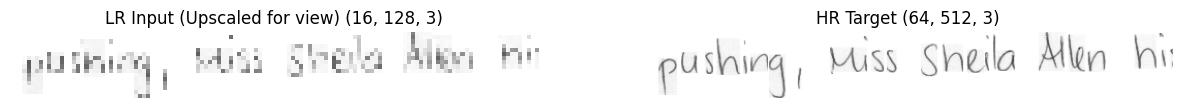

In [14]:
import matplotlib.pyplot as plt

for lr_batch, hr_batch in train_ds.take(1):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    plt.title(f"LR Input (Upscaled for view) {lr_batch[0].shape}")
    plt.imshow((lr_batch[0].numpy() + 1.0) / 2.0)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"HR Target {hr_batch[0].shape}")
    plt.imshow((hr_batch[0].numpy() + 1.0) / 2.0)
    plt.axis('off')

    plt.show()

In [15]:
from tensorflow.keras import layers, Model
import tensorflow as tf

def residual_block(x, filters=64):
    """Standard SRGAN Residual Block"""
    res = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
    res = layers.BatchNormalization()(res)
    res = layers.PReLU(shared_axes=[1, 2])(res)
    res = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(res)
    res = layers.BatchNormalization()(res)
    return layers.Add()([x, res])

def upscale_block(x, filters=256):
    """Upscaling via PixelShuffle wrapped in a Lambda layer"""
    x = layers.Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
    x = layers.Lambda(lambda z: tf.nn.depth_to_space(z, block_size=2))(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    return x

def build_generator(input_shape=(16, 128, 3), num_res_blocks=5):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, kernel_size=9, strides=1, padding='same')(inputs)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    pre_res = x

    for _ in range(num_res_blocks):
        x = residual_block(x, filters=64)

    x = layers.Conv2D(64, kernel_size=3, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([pre_res, x])

    x = upscale_block(x, filters=256)
    x = upscale_block(x, filters=256)

    outputs = layers.Conv2D(3, kernel_size=9, strides=1, padding='same', activation='tanh')(x)

    return Model(inputs, outputs, name="Generator")

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 128,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 128,   │     15,616 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu (PReLU)     │ (None, 16, 128,   │         64 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 128,   │     36,928 │ p_re_lu[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16, 128,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_1 (PReLU)   │ (None, 16, 128,   │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 128,   │     36,928 │ p_re_lu_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 128,   │          0 │ p_re_lu[0][0],    │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 128,   │     36,928 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_2 (PReLU)   │ (None, 16, 128,   │         64 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 128,   │     36,928 │ p_re_lu_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 128,   │          0 │ add[0][0],        │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 128,   │     36,928 │ add_1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 128,   │        256 │ conv2d_5[0][0]  

 Total params: 736,131 (2.81 MB)

 Trainable params: 734,723 (2.80 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [16]:
def discriminator_block(x, filters, strides=1):
    x = layers.Conv2D(filters, kernel_size=3, strides=strides, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    return x

def build_discriminator(input_shape=(64, 512, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, kernel_size=3, strides=1, padding='same')(inputs)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = discriminator_block(x, 64, strides=2)
    x = discriminator_block(x, 128, strides=1)
    x = discriminator_block(x, 128, strides=2)
    x = discriminator_block(x, 256, strides=1)
    x = discriminator_block(x, 256, strides=2)
    x = discriminator_block(x, 512, strides=1)
    x = discriminator_block(x, 512, strides=2)

    x = layers.Flatten()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x) # And here
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return Model(inputs, outputs, name="Discriminator")

discriminator = build_discriminator()

In [17]:
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 512, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 512, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 512, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 256, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 256, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 256, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 256, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 256, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 256, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 128, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 128, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 128, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 128, 256)   │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 128, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 128, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 64, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 64, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 64, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 64, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 64, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 64, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 4, 32, 512)     │     2,359,80

 Total params: 71,803,713 (273.91 MB)

 Trainable params: 71,800,001 (273.90 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [18]:
from tensorflow.keras.applications.vgg19 import VGG19

def build_vgg_loss_model():
    vgg = VGG19(include_top=False, weights='imagenet', input_shape=(HR_HEIGHT, HR_WIDTH, 3))
    vgg.trainable = False

    model = Model(inputs=vgg.input, outputs=vgg.layers[20].output)
    return model

vgg_model = build_vgg_loss_model()

def calculate_vgg_loss(real, fake):

    real_vgg = (real + 1.0) / 2.0
    fake_vgg = (fake + 1.0) / 2.0

    real_features = vgg_model(real_vgg)
    fake_features = vgg_model(fake_vgg)

    return tf.reduce_mean(tf.square(real_features - fake_features))

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [19]:
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy()
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.9)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.9)

@tf.function
def train_step(lr_images, hr_images):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(lr_images, training=True)

        real_output = discriminator(hr_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        adversarial_loss = binary_cross_entropy(tf.ones_like(fake_output), fake_output)
        vgg_loss = calculate_vgg_loss(hr_images, generated_images)
        gen_loss = vgg_loss + (1e-3 * adversarial_loss)

        real_loss = binary_cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = binary_cross_entropy(tf.zeros_like(fake_output), fake_output)
        disc_loss = real_loss + fake_loss

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [20]:
def plot_training_progress(generator_model, epoch, dataset):
    for lr_batch, hr_batch in dataset.take(1):
        pred_hr = generator_model.predict(lr_batch)

        lr_plot = (lr_batch[0].numpy() + 1.0) / 2.0
        pred_plot = (pred_hr[0] + 1.0) / 2.0
        hr_plot = (hr_batch[0].numpy() + 1.0) / 2.0

        plt.figure(figsize=(20, 6))

        plt.subplot(1, 3, 1)
        plt.title(f"LR Input (Epoch {epoch})")
        plt.imshow(lr_plot)
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.title("SRGAN Prediction")
        plt.imshow(pred_plot)
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.title("HR Ground Truth")
        plt.imshow(hr_plot)
        plt.axis('off')

        plt.tight_layout()
        plt.show()

  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 1: Gen Loss = 0.0680, Disc Loss = 0.2629
Time: 616.25s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 2: Gen Loss = 0.0341, Disc Loss = 0.7008
Time: 579.97s


  0%|          | 0/835 [00:00<?, ?it/s]

...


Epoch 8: Gen Loss = 0.0104, Disc Loss = 0.9276
Time: 581.28s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 9: Gen Loss = 0.0100, Disc Loss = 0.8216
Time: 580.99s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 10: Gen Loss = 0.0109, Disc Loss = 0.7451
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


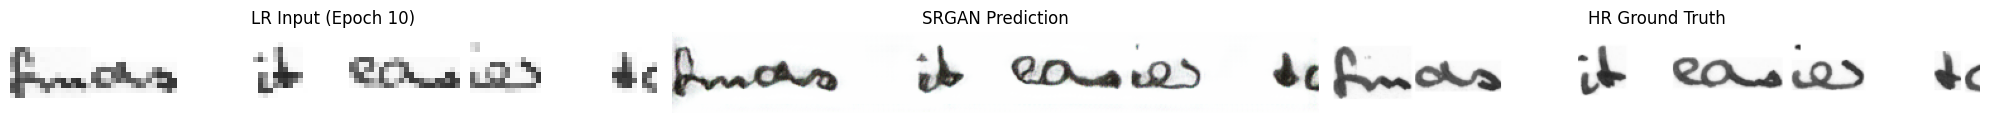

Time: 581.19s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 11: Gen Loss = 0.0103, Disc Loss = 0.7104
Time: 581.33s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 12: Gen Loss = 0.0101, Disc Loss = 0.6904
Time: 581.14s


...


Epoch 18: Gen Loss = 0.0101, Disc Loss = 0.5879
Time: 581.63s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 19: Gen Loss = 0.0103, Disc Loss = 0.6294
Time: 580.83s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 20: Gen Loss = 0.0101, Disc Loss = 0.6037
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


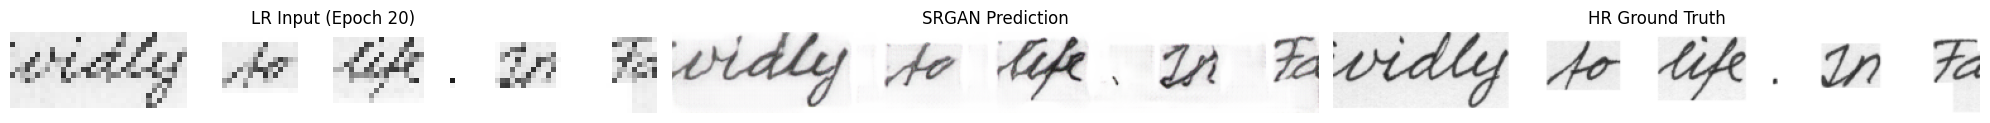

Time: 581.38s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 21: Gen Loss = 0.0100, Disc Loss = 0.5677
Time: 581.20s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 22: Gen Loss = 0.0101, Disc Loss = 0.5732
Time: 582.18s


...

  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 26: Gen Loss = 0.0101, Disc Loss = 0.5725
Time: 582.13s


  0%|          | 0/835 [00:00<?, ?it/s]


Epoch 27: Gen Loss = 0.0101, Disc Loss = 0.4957
Time: 581.31s


  0%|          | 0/835 [00:00<?, ?it/s]

In [ ]:
EPOCHS = 50

for epoch in range(EPOCHS):
    start = time.time()
    gen_loss_list, disc_loss_list = [], []

    for lr_batch, hr_batch in tqdm(train_ds):
        g_loss, d_loss = train_step(lr_batch, hr_batch)
        gen_loss_list.append(g_loss)
        disc_loss_list.append(d_loss)

    print(f"\nEpoch {epoch+1}: Gen Loss = {np.mean(gen_loss_list):.4f}, Disc Loss = {np.mean(disc_loss_list):.4f}")

    if (epoch + 1) % 10 == 0:
        plot_training_progress(generator, epoch + 1, train_ds)
        generator.save(f'srgan_gen_epoch_{epoch+1}.h5')

    print(f"Time: {time.time()-start:.2f}s")